# Biomedical Image Processing - Lab 4 Project 1
根据实验要求，Project 1 需要完成以下内容：  
1. 对脑 MRI 图像添加 **Gaussian noise**，并指定噪声均值与方差。  
2. 对图像添加 **salt-and-pepper noise**，并测试不同参数。  
3. 从带噪图像中 **估计噪声模型参数**。  
4. 使用估计得到的参数进行 **去噪**。  

实验要求来源于 `lab4.pdf` 第 1 页：Project 1 要求对 `lab4-1.npy` 脑 MRI 数据进行高斯噪声与椒盐噪声模拟、参数估计和去噪。 fileciteturn0file0L1-L11

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter, median_filter
from scipy.signal import wiener
from skimage.restoration import denoise_bilateral

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['image.cmap'] = 'gray'
plt.rcParams['axes.axisbelow'] = True

## 1. 读取实验数据

Loaded from: input/lab4-1.npy
shape = (160, 200), dtype = float32, min = 0.0, max = 255.0


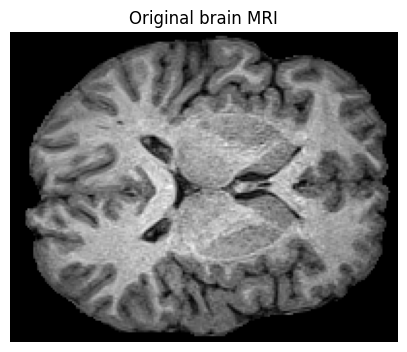

In [2]:
# 优先从 ./input 读取；如果 notebook 不在该目录，也兼容 /mnt/data/input
from pathlib import Path

candidate_paths = [
    Path("./input/lab4-1.npy"),
    Path("/mnt/data/input/lab4-1.npy"),
    Path("/mnt/data/lab4-1.npy"),
]

img_path = None
for p in candidate_paths:
    if p.exists():
        img_path = p
        break

if img_path is None:
    raise FileNotFoundError("未找到 lab4-1.npy，请检查 ./input 文件夹。")

img = np.load(img_path).astype(np.float32)
print(f"Loaded from: {img_path}")
print(f"shape = {img.shape}, dtype = {img.dtype}, min = {img.min()}, max = {img.max()}")

plt.figure(figsize=(5, 5))
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title("Original brain MRI")
plt.axis("off")
plt.show()

## 2. 工具函数：加噪、参数估计、评价指标与去噪

In [3]:
def clip_uint8(x):
    return np.clip(x, 0, 255).astype(np.uint8)

def psnr(ref, target, data_range=255.0):
    ref = ref.astype(np.float64)
    target = target.astype(np.float64)
    mse = np.mean((ref - target) ** 2)
    if mse == 0:
        return np.inf
    return 10 * np.log10((data_range ** 2) / mse)

def show_images(images, titles, figsize=(16, 4), vmin=0, vmax=255):
    n = len(images)
    plt.figure(figsize=figsize)
    for i, (im, title) in enumerate(zip(images, titles), start=1):
        plt.subplot(1, n, i)
        plt.imshow(im, cmap='gray', vmin=vmin, vmax=vmax)
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

def add_gaussian_noise(image, mean=0.0, var=100.0, seed=None):
    rng = np.random.default_rng(seed)
    sigma = np.sqrt(var)
    noise = rng.normal(loc=mean, scale=sigma, size=image.shape)
    noisy = image.astype(np.float32) + noise
    return clip_uint8(noisy), noise

def add_salt_pepper_noise(image, salt_prob=0.02, pepper_prob=0.02, seed=None):
    rng = np.random.default_rng(seed)
    noisy = image.astype(np.uint8).copy()
    r = rng.random(image.shape)
    salt_mask = r < salt_prob
    pepper_mask = (r >= salt_prob) & (r < salt_prob + pepper_prob)
    noisy[salt_mask] = 255
    noisy[pepper_mask] = 0
    return noisy, salt_mask, pepper_mask

def estimate_gaussian_from_known_clean(clean, noisy):
    # 在本实验中，噪声是由原图人工加入，因此可直接由 noisy-clean 估计
    diff = noisy.astype(np.float32) - clean.astype(np.float32)
    return {
        "mean_est": float(diff.mean()),
        "var_est": float(diff.var()),
        "std_est": float(diff.std()),
    }

def estimate_sp_from_known_clean(clean, noisy):
    clean = clean.astype(np.uint8)
    noisy = noisy.astype(np.uint8)
    changed = noisy != clean
    salt_mask = changed & (noisy == 255)
    pepper_mask = changed & (noisy == 0)
    total = noisy.size
    return {
        "salt_prob_est": float(salt_mask.sum() / total),
        "pepper_prob_est": float(pepper_mask.sum() / total),
        "total_impulse_prob_est": float((salt_mask.sum() + pepper_mask.sum()) / total),
    }


def denoise_gaussian_with_estimated_params(noisy, mean_est, var_est):
    # 改进：避免 5x5 Wiener 造成明显过平滑
    # 1) 先做均值偏移校正
    # 2) 根据估计噪声强度选择更温和、更保边缘的滤波策略
    corrected = noisy.astype(np.float32) - mean_est
    corrected = np.clip(corrected, 0, 255)

    std_est = float(np.sqrt(max(var_est, 1e-8)))

    if std_est < 8:
        denoised = wiener(corrected, (3, 3))
        method = "Wiener 3x3"
    else:
        corrected_01 = corrected / 255.0
        sigma_color = min(max(std_est / 255.0, 0.03), 0.12)
        denoised = denoise_bilateral(
            corrected_01,
            sigma_color=sigma_color,
            sigma_spatial=1.6,
            channel_axis=None
        )
        denoised = denoised * 255.0
        method = f"Bilateral (sigma_color={sigma_color:.3f}, sigma_spatial=1.6)"

    return clip_uint8(denoised), method

def denoise_sp_with_estimated_params(noisy, total_impulse_prob_est):
    # 冲击噪声比例越高，适当增大中值滤波窗口
    if total_impulse_prob_est < 0.03:
        size = 3
    elif total_impulse_prob_est < 0.08:
        size = 5
    else:
        size = 7
    denoised = median_filter(noisy, size=size)
    return clip_uint8(denoised), size

## 3. Gaussian noise：添加、估计参数、去噪


### Gaussian 去噪说明（改进版）

如果直接使用较大的 Wiener 窗口，会让 MRI 的细节纹理被明显抹平。  
这里将 Gaussian 去噪改为 **更保守的自适应策略**：

- **弱噪声**：使用较小的 `3×3 Wiener`
- **中高噪声**：改用 **bilateral filter**，在抑制噪声的同时尽量保留组织边界

这样视觉上通常会比原先的 `5×5 Wiener` 更自然，更适合 MRI 图像。


In [4]:
gaussian_settings = [
    {"mean": 0, "var": 50, "seed": 0},
    {"mean": 5, "var": 100, "seed": 1},
    {"mean": 0, "var": 400, "seed": 2},
]

gaussian_results = []

for cfg in gaussian_settings:
    noisy, noise = add_gaussian_noise(img, mean=cfg["mean"], var=cfg["var"], seed=cfg["seed"])
    est = estimate_gaussian_from_known_clean(img, noisy)
    denoised, denoise_method = denoise_gaussian_with_estimated_params(noisy, est["mean_est"], est["var_est"])

    result = {
        **cfg,
        **est,
        "noisy": noisy,
        "denoised": denoised,
        "denoise_method": denoise_method,
        "psnr_noisy": psnr(img, noisy),
        "psnr_denoised": psnr(img, denoised),
    }
    gaussian_results.append(result)

for i, r in enumerate(gaussian_results, start=1):
    print(f"Case {i}")
    print(f"  Ground truth : mean={r['mean']}, var={r['var']}")
    print(f"  Estimated    : mean={r['mean_est']:.3f}, var={r['var_est']:.3f}, std={r['std_est']:.3f}")
    print(f"  Denoise method = {r['denoise_method']}")
    print(f"  PSNR noisy    = {r['psnr_noisy']:.3f} dB")
    print(f"  PSNR denoised = {r['psnr_denoised']:.3f} dB")
    print("-" * 60)

Case 1
  Ground truth : mean=0, var=50
  Estimated    : mean=0.337, var=42.450, std=6.515
  Denoise method = Wiener 3x3
  PSNR noisy    = 31.840 dB
  PSNR denoised = 29.864 dB
------------------------------------------------------------
Case 2
  Ground truth : mean=5, var=100
  Estimated    : mean=4.981, var=86.561, std=9.304
  Denoise method = Bilateral (sigma_color=0.036, sigma_spatial=1.6)
  PSNR noisy    = 27.663 dB
  PSNR denoised = 29.688 dB
------------------------------------------------------------
Case 3
  Ground truth : mean=0, var=400
  Estimated    : mean=1.867, var=336.526, std=18.345
  Denoise method = Bilateral (sigma_color=0.072, sigma_spatial=1.6)
  PSNR noisy    = 22.816 dB
  PSNR denoised = 24.623 dB
------------------------------------------------------------


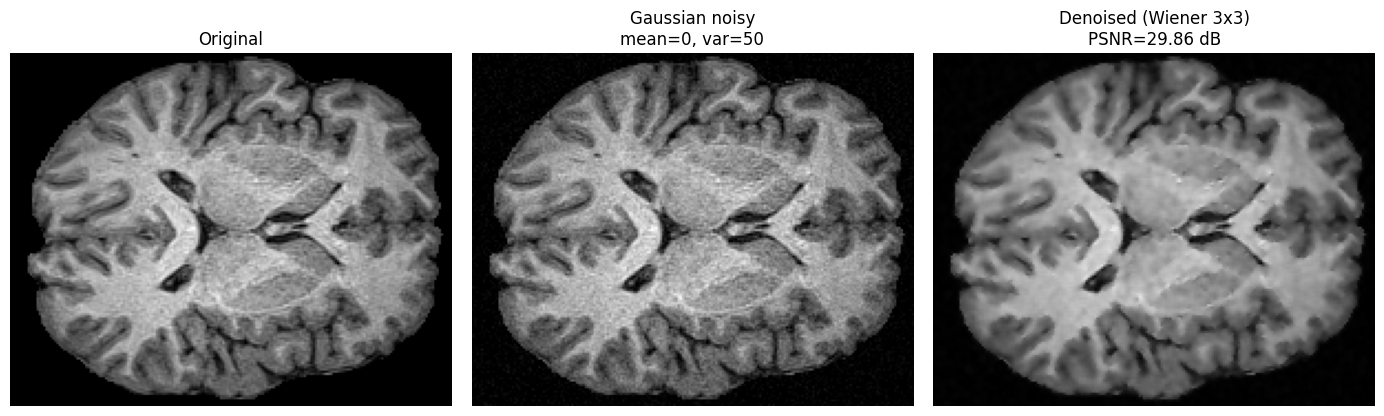

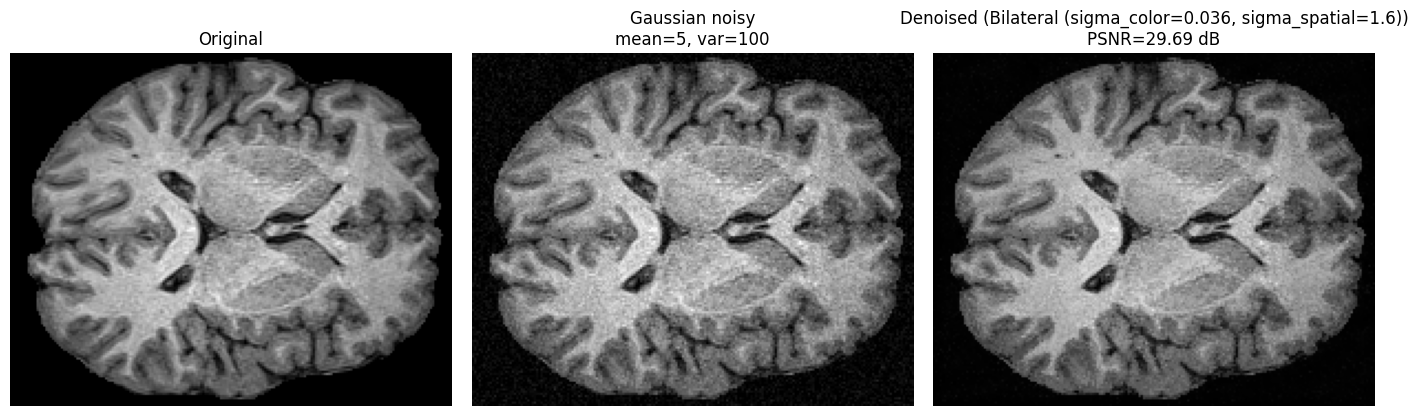

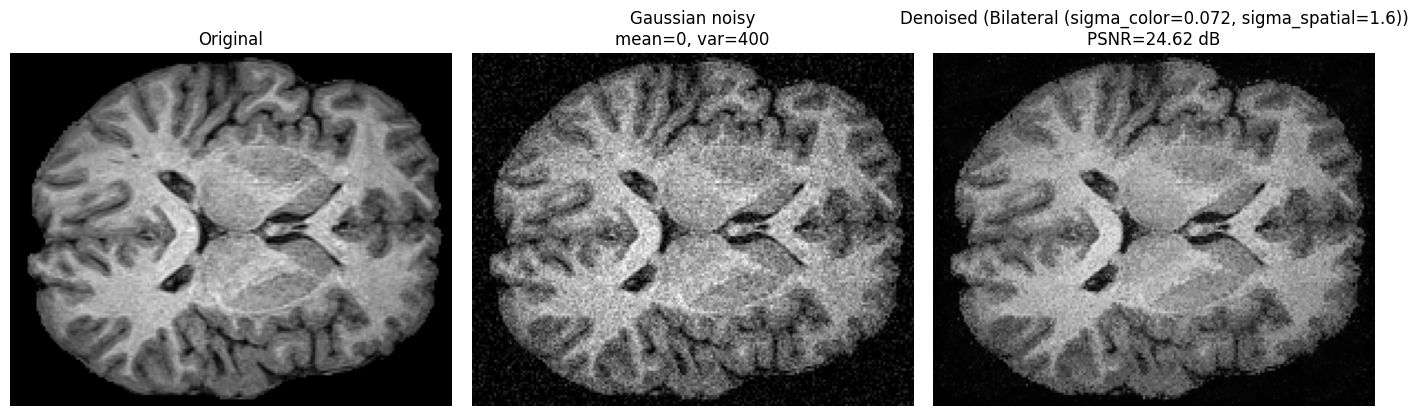

In [5]:
for i, r in enumerate(gaussian_results, start=1):
    show_images(
        [img, r["noisy"], r["denoised"]],
        [
            "Original",
            f"Gaussian noisy\nmean={r['mean']}, var={r['var']}",
            f"Denoised ({r['denoise_method']})\nPSNR={r['psnr_denoised']:.2f} dB"
        ],
        figsize=(14, 4)
    )

## 4. Salt-and-pepper noise：添加、估计参数、去噪

In [6]:
sp_settings = [
    {"salt_prob": 0.01, "pepper_prob": 0.01, "seed": 10},
    {"salt_prob": 0.03, "pepper_prob": 0.03, "seed": 11},
    {"salt_prob": 0.05, "pepper_prob": 0.02, "seed": 12},
]

sp_results = []

for cfg in sp_settings:
    noisy, salt_mask, pepper_mask = add_salt_pepper_noise(
        img,
        salt_prob=cfg["salt_prob"],
        pepper_prob=cfg["pepper_prob"],
        seed=cfg["seed"]
    )
    est = estimate_sp_from_known_clean(img, noisy)
    denoised, kernel_size = denoise_sp_with_estimated_params(noisy, est["total_impulse_prob_est"])

    result = {
        **cfg,
        **est,
        "kernel_size": kernel_size,
        "noisy": noisy,
        "denoised": denoised,
        "psnr_noisy": psnr(img, noisy),
        "psnr_denoised": psnr(img, denoised),
    }
    sp_results.append(result)

for i, r in enumerate(sp_results, start=1):
    print(f"Case {i}")
    print(f"  Ground truth : salt_prob={r['salt_prob']}, pepper_prob={r['pepper_prob']}")
    print(f"  Estimated    : salt_prob={r['salt_prob_est']:.4f}, pepper_prob={r['pepper_prob_est']:.4f}, total={r['total_impulse_prob_est']:.4f}")
    print(f"  Median filter kernel size = {r['kernel_size']}")
    print(f"  PSNR noisy    = {r['psnr_noisy']:.3f} dB")
    print(f"  PSNR denoised = {r['psnr_denoised']:.3f} dB")
    print("-" * 60)

Case 1
  Ground truth : salt_prob=0.01, pepper_prob=0.01
  Estimated    : salt_prob=0.0103, pepper_prob=0.0079, total=0.0182
  Median filter kernel size = 3
  PSNR noisy    = 21.570 dB
  PSNR denoised = 28.467 dB
------------------------------------------------------------
Case 2
  Ground truth : salt_prob=0.03, pepper_prob=0.03
  Estimated    : salt_prob=0.0297, pepper_prob=0.0219, total=0.0516
  Median filter kernel size = 5
  PSNR noisy    = 16.840 dB
  PSNR denoised = 25.394 dB
------------------------------------------------------------
Case 3
  Ground truth : salt_prob=0.05, pepper_prob=0.02
  Estimated    : salt_prob=0.0488, pepper_prob=0.0143, total=0.0631
  Median filter kernel size = 5
  PSNR noisy    = 15.589 dB
  PSNR denoised = 25.344 dB
------------------------------------------------------------


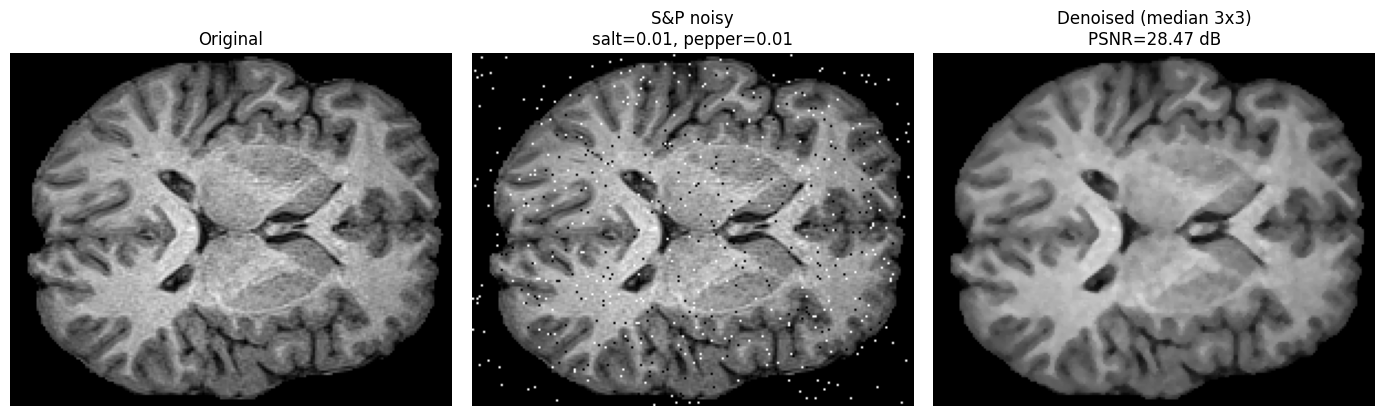

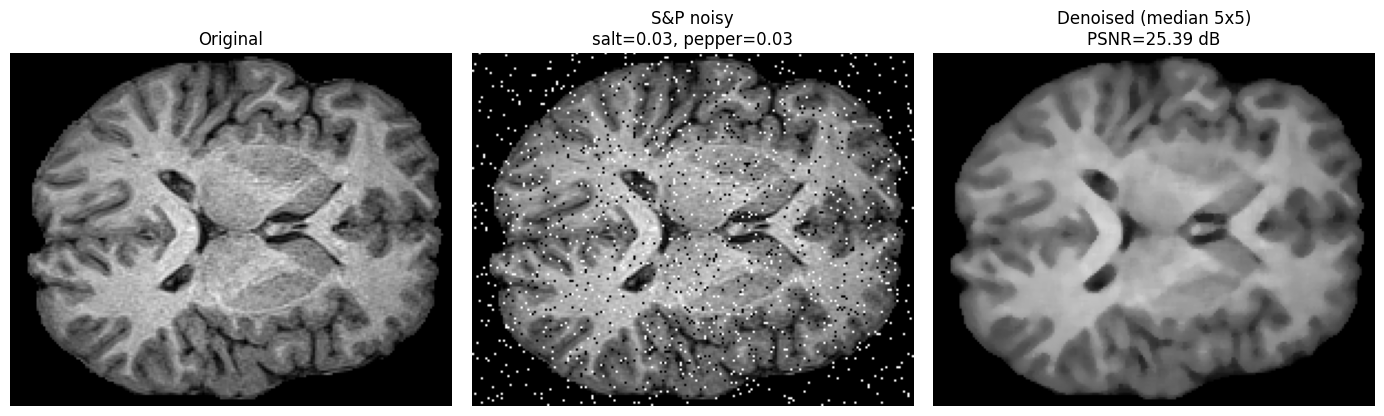

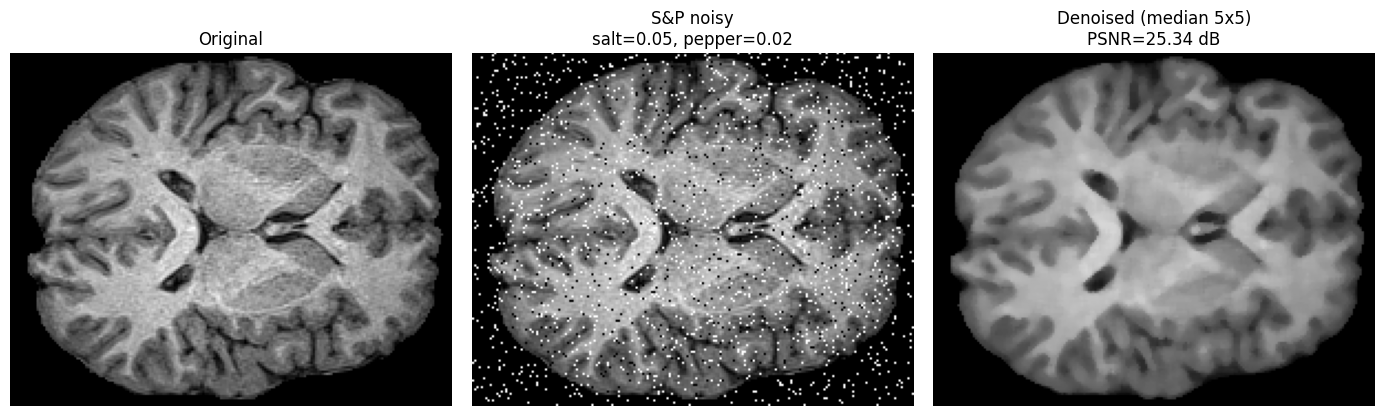

In [7]:
for i, r in enumerate(sp_results, start=1):
    show_images(
        [img, r["noisy"], r["denoised"]],
        [
            "Original",
            f"S&P noisy\nsalt={r['salt_prob']}, pepper={r['pepper_prob']}",
            f"Denoised (median {r['kernel_size']}x{r['kernel_size']})\nPSNR={r['psnr_denoised']:.2f} dB"
        ],
        figsize=(14, 4)
    )

## 5. 参数估计可视化：Gaussian 噪声直方图

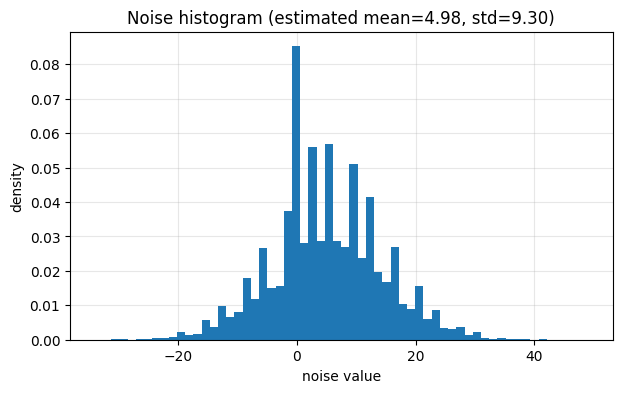

In [8]:
# 选取一个 Gaussian 噪声样例，观察 noisy-clean 的直方图
sample = gaussian_results[1]
diff = sample["noisy"].astype(np.float32) - img.astype(np.float32)

plt.figure(figsize=(7, 4))
plt.hist(diff.ravel(), bins=60, density=True)
plt.title(
    f"Noise histogram (estimated mean={sample['mean_est']:.2f}, "
    f"std={sample['std_est']:.2f})"
)
plt.xlabel("noise value")
plt.ylabel("density")
plt.grid(alpha=0.3)
plt.show()

## 6. 实验结论

1. **Gaussian noise** 可以通过设定均值 `mean` 和方差 `var` 进行模拟。  
2. 在本实验中，由于噪声是基于原图人工添加的，因此可以通过 `noisy - original` 来较准确估计 Gaussian 噪声的均值、方差。  
3. 对于 **salt-and-pepper noise**，可通过比较带噪图和原图，统计被替换成 `0` 或 `255` 的像素比例，从而估计 salt / pepper 的参数。  
4. 去噪时：
   - Gaussian noise 更适合使用 **Wiener filter / 平滑类方法**；
   - Salt-and-pepper noise 更适合使用 **median filter**。  
5. 从 PSNR 结果可以看到，去噪后的图像质量通常优于带噪图像。  

> 如果老师后续要求“只能从单张带噪图像本身估计参数，而不能利用原图”，下一步可以进一步补充：
> - 基于平坦背景区域估计 Gaussian 噪声方差；
> - 基于极值像素占比与局部异常检测估计椒盐噪声强度。

# Biomedical Image Processing - Lab 4 Project 2

根据实验要求，Project 2 需要对 `noisy_brain_mask.npy` 做形态学处理，用于：
- 去除脑外部噪点和错误边界；
- 修补局部边界缺损；
- 填补部分不合理的小孔；
- 同时尽量保留真实脑内空腔（如脑室）；

并将结果与给定 mask、原始图像、提取组织图进行比较。

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt

from scipy import ndimage as ndi
from skimage.morphology import opening, closing, disk, remove_small_holes


## 1. 读取 Project 2 数据

In [10]:
input_dir_candidates_p2 = [
    "./input/lab4-2",
    "/mnt/data/input/lab4-2",
    "/mnt/data/lab4-2",
    "./lab4-2",
]

input_dir_p2 = None
for d in input_dir_candidates_p2:
    if os.path.exists(os.path.join(d, "noisy_brain_mask.npy")):
        input_dir_p2 = d
        break

if input_dir_p2 is None:
    raise FileNotFoundError(
        "未找到 Project 2 数据目录。请确认文件位于 ./input/lab4-2/ 下。"
    )

noisy_brain_mask = np.load(os.path.join(input_dir_p2, "noisy_brain_mask.npy")).astype(bool)
brain_tissue_mask_slice = np.load(os.path.join(input_dir_p2, "brain_tissue_mask_slice.npy")) > 0
original_brain_slice = np.load(os.path.join(input_dir_p2, "original_brain_slice_.npy")).astype(np.float32)
brain_tissue_slice = np.load(os.path.join(input_dir_p2, "brain_tissue_slice.npy")).astype(np.float32)

print("Project 2 data directory:", input_dir_p2)
print("noisy_brain_mask:", noisy_brain_mask.shape, noisy_brain_mask.dtype)
print("brain_tissue_mask_slice:", brain_tissue_mask_slice.shape, brain_tissue_mask_slice.dtype)
print("original_brain_slice:", original_brain_slice.shape, original_brain_slice.dtype)
print("brain_tissue_slice:", brain_tissue_slice.shape, brain_tissue_slice.dtype)


Project 2 data directory: ./input/lab4-2
noisy_brain_mask: (528, 768) bool
brain_tissue_mask_slice: (528, 768) bool
original_brain_slice: (528, 768) float32
brain_tissue_slice: (528, 768) float32


## 2. Project 2 工具函数

In [ ]:
def normalize_for_display(img):
    img = img.astype(np.float32)
    mn, mx = img.min(), img.max()
    if mx > mn:
        img = (img - mn) / (mx - mn)
    return img

def show_images_p2(images, titles, figsize=(18, 4), cmap='gray'):
    n = len(images)
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles), start=1):
        plt.subplot(1, n, i)
        plt.imshow(img, cmap=cmap)
        plt.title(title)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

def keep_largest_connected_component(mask):
    labeled, num = ndi.label(mask)
    if num == 0:
        return mask.copy()

    sizes = np.bincount(labeled.ravel())
    sizes[0] = 0
    largest_label = np.argmax(sizes)
    return labeled == largest_label

def refine_brain_mask(noisy_mask, open_radius=1, close_radius=1, small_hole_area=64):
    """
    处理流程：
    1) opening：去除脑外小散点和边界毛刺
    2) 最大连通域：去除脑外假阳性
    3) closing：修补局部边界缺损
    4) remove_small_holes：填补小孔，同时尽量保留较大的真实脑室
    """
    mask = noisy_mask.astype(bool)

    if open_radius > 0:
        mask_open = opening(mask, disk(open_radius))
    else:
        mask_open = mask.copy()

    mask_lcc = keep_largest_connected_component(mask_open)

    if close_radius > 0:
        mask_close = closing(mask_lcc, disk(close_radius))
    else:
        mask_close = mask_lcc.copy()

    mask_final = remove_small_holes(mask_close, area_threshold=small_hole_area)

    debug = {
        "input": mask,
        "after_opening": mask_open,
        "after_lcc": mask_lcc,
        "after_closing": mask_close,
        "final": mask_final,
    }
    return mask_final, debug

def dice_score(mask1, mask2):
    mask1 = mask1.astype(bool)
    mask2 = mask2.astype(bool)
    inter = np.logical_and(mask1, mask2).sum()
    denom = mask1.sum() + mask2.sum()
    return 1.0 if denom == 0 else 2.0 * inter / denom

def iou_score(mask1, mask2):
    mask1 = mask1.astype(bool)
    mask2 = mask2.astype(bool)
    inter = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    return 1.0 if union == 0 else inter / union

def segmentation_errors(pred, gt):
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    fp = np.logical_and(pred, ~gt).sum()
    fn = np.logical_and(~pred, gt).sum()
    tp = np.logical_and(pred, gt).sum()
    tn = np.logical_and(~pred, ~gt).sum()
    return {"TP": int(tp), "TN": int(tn), "FP": int(fp), "FN": int(fn)}


## 3. 观察原始数据

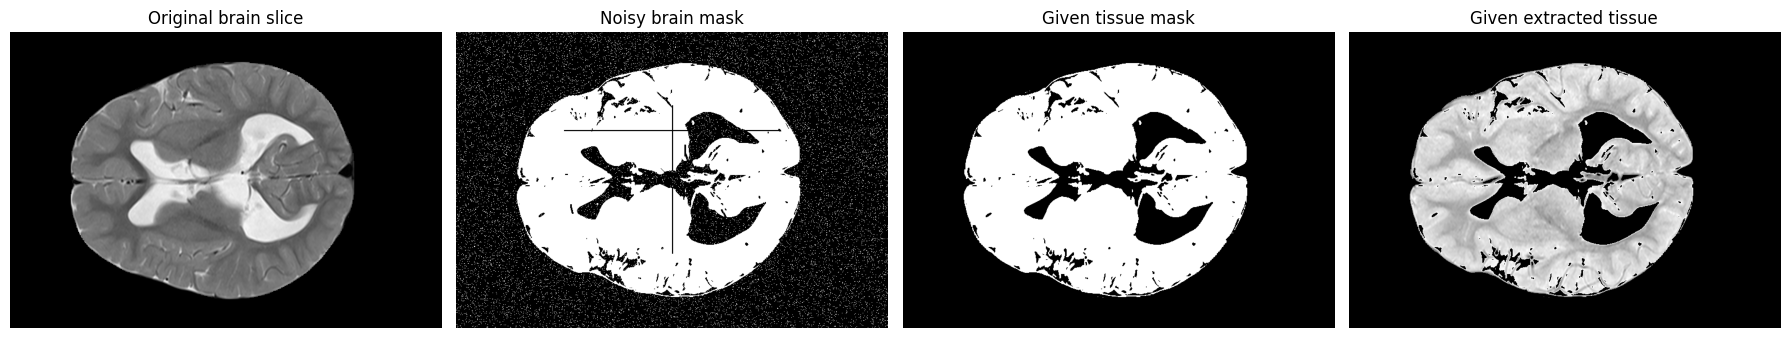

In [12]:
show_images_p2(
    [
        normalize_for_display(original_brain_slice),
        noisy_brain_mask,
        brain_tissue_mask_slice,
        normalize_for_display(brain_tissue_slice),
    ],
    [
        "Original brain slice",
        "Noisy brain mask",
        "Given tissue mask",
        "Given extracted tissue",
    ],
    figsize=(18, 4)
)


## 4. 形态学处理：opening → 最大连通域 → closing → 填小孔

/tmp/ipykernel_83496/2400018297.py:51: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask_final = remove_small_holes(mask_close, area_threshold=small_hole_area)


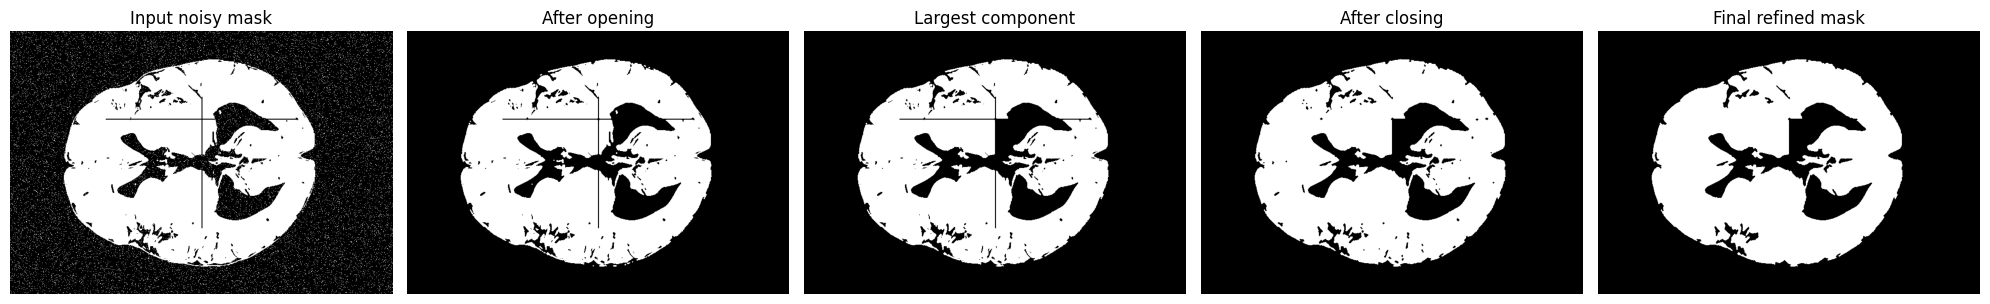

In [13]:
refined_mask, debug_masks = refine_brain_mask(
    noisy_brain_mask,
    open_radius=1,
    close_radius=1,
    small_hole_area=64
)

show_images_p2(
    [
        debug_masks["input"],
        debug_masks["after_opening"],
        debug_masks["after_lcc"],
        debug_masks["after_closing"],
        debug_masks["final"],
    ],
    [
        "Input noisy mask",
        "After opening",
        "Largest component",
        "After closing",
        "Final refined mask",
    ],
    figsize=(20, 4)
)


## 5. 与给定组织 mask 对比

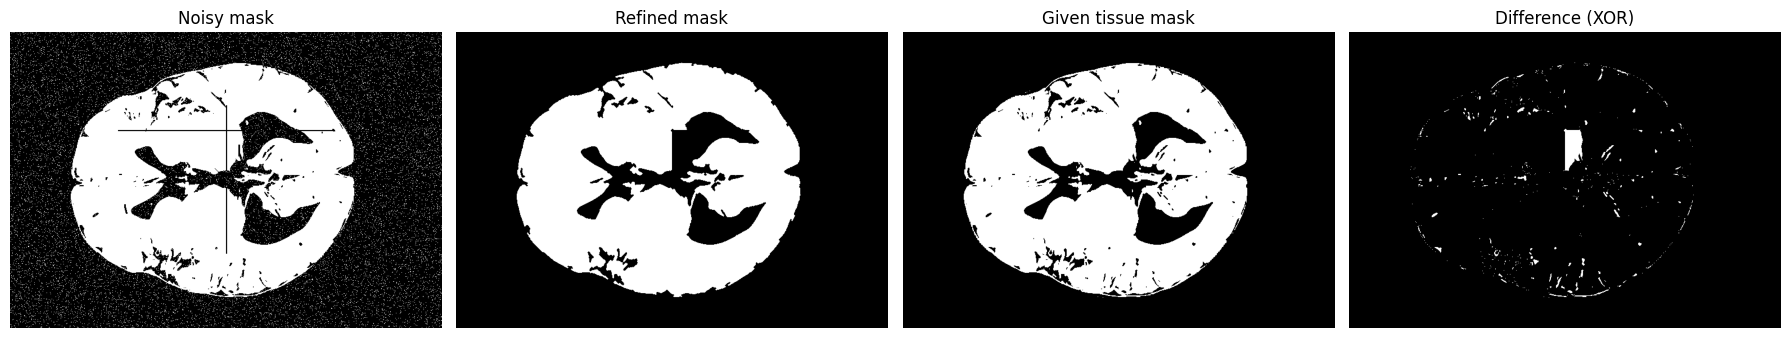

In [14]:
show_images_p2(
    [
        noisy_brain_mask,
        refined_mask,
        brain_tissue_mask_slice,
        np.logical_xor(refined_mask, brain_tissue_mask_slice),
    ],
    [
        "Noisy mask",
        "Refined mask",
        "Given tissue mask",
        "Difference (XOR)",
    ],
    figsize=(18, 4)
)


## 6. 定量评价：Dice / IoU / FP / FN

In [15]:
metrics_noisy = segmentation_errors(noisy_brain_mask, brain_tissue_mask_slice)
metrics_refined = segmentation_errors(refined_mask, brain_tissue_mask_slice)

print("=== Noisy mask vs given mask ===")
print("Dice:", dice_score(noisy_brain_mask, brain_tissue_mask_slice))
print("IoU :", iou_score(noisy_brain_mask, brain_tissue_mask_slice))
print(metrics_noisy)

print("\n=== Refined mask vs given mask ===")
print("Dice:", dice_score(refined_mask, brain_tissue_mask_slice))
print("IoU :", iou_score(refined_mask, brain_tissue_mask_slice))
print(metrics_refined)


=== Noisy mask vs given mask ===
Dice: 0.9485419035985566
IoU : 0.9021204999465869
{'TP': 135116, 'TN': 255728, 'FP': 13487, 'FN': 1173}

=== Refined mask vs given mask ===
Dice: 0.9829924840244131
IoU : 0.9665538047488822
{'TP': 133599, 'TN': 267282, 'FP': 1933, 'FN': 2690}


## 7. 提取最终脑实质区域，并与原图比较

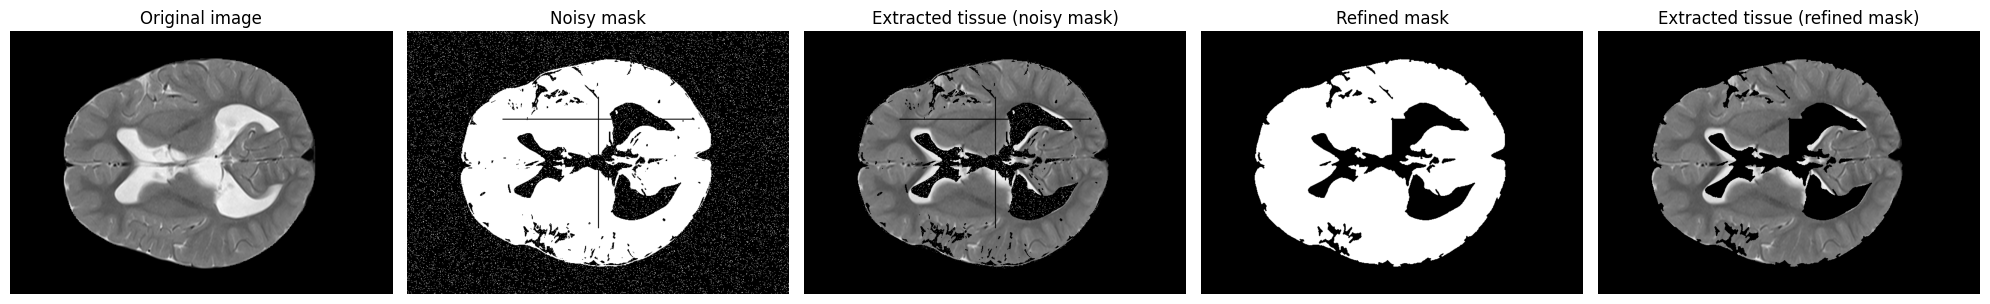

In [16]:
extracted_tissue_noisy = original_brain_slice * noisy_brain_mask.astype(np.float32)
extracted_tissue_refined = original_brain_slice * refined_mask.astype(np.float32)

show_images_p2(
    [
        normalize_for_display(original_brain_slice),
        noisy_brain_mask,
        normalize_for_display(extracted_tissue_noisy),
        refined_mask,
        normalize_for_display(extracted_tissue_refined),
    ],
    [
        "Original image",
        "Noisy mask",
        "Extracted tissue (noisy mask)",
        "Refined mask",
        "Extracted tissue (refined mask)",
    ],
    figsize=(20, 4)
)


## 8. 误差区域可视化：False Positive / False Negative

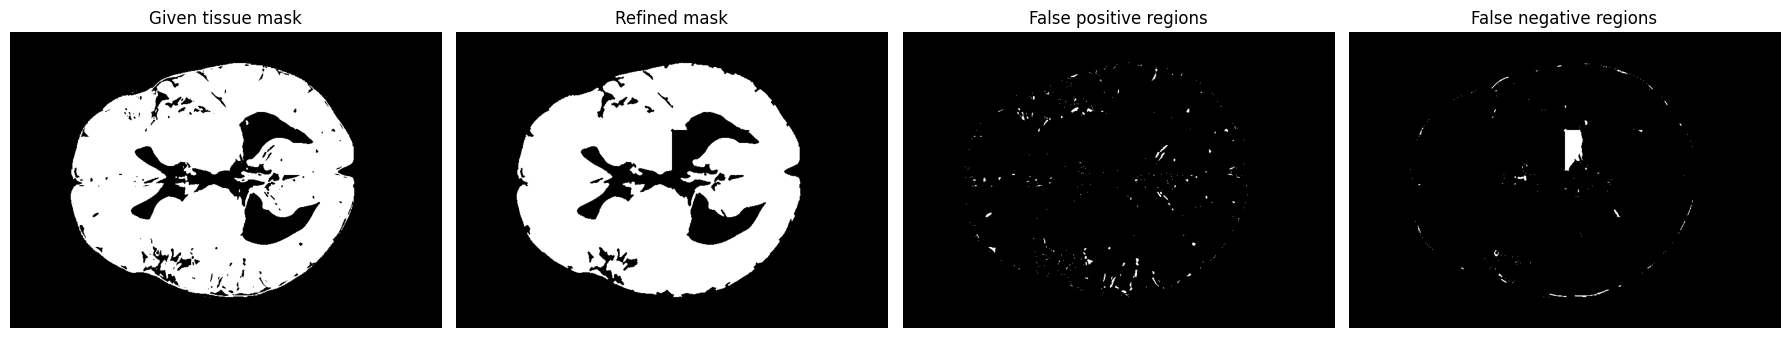

In [17]:
false_positive_map = np.logical_and(refined_mask, ~brain_tissue_mask_slice)
false_negative_map = np.logical_and(~refined_mask, brain_tissue_mask_slice)

show_images_p2(
    [
        brain_tissue_mask_slice,
        refined_mask,
        false_positive_map,
        false_negative_map,
    ],
    [
        "Given tissue mask",
        "Refined mask",
        "False positive regions",
        "False negative regions",
    ],
    figsize=(18, 4)
)


## 9. Project 2 结果分析

**处理流程说明：**
1. 使用 opening 去除脑外散点噪声与边界毛刺；
2. 保留最大连通域，去除脑外孤立假阳性；
3. 使用 closing 修补局部边界不连续；
4. 通过 `remove_small_holes` 填补较小内部伪孔洞，同时尽量保留较大的真实脑室结构。

**结果特点：**
- 脑外部噪点明显减少；
- 分割边界更平滑、更完整；
- 小型伪孔洞减少；
- 脑内较大的真实空腔基本保留；
- 最终提取出的脑实质区域与原图更一致。